# final projet

## 说明
环境：python3.9.7
使用的包：<br/>
pandas 1.3.4 <br/>
numpy 1.22.0 <br/>
matplotlib.pyplot 3.5.1<br/>
seaborn 0.11.2<br/>
math 内置<br/>
plotnine 0.8.0<br/>
scikit-learn 1.0.2 <br/>
itertools 内置<br/>

## 1.导入所需要的包

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_profiling as pp
import seaborn as sns
import math
from plotnine import *
from numpy import interp
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

## 2.定义数据集类

In [150]:
class Dataset():
    def __init__(self, X, y):
        try:
            values_X = X.values
            values_y = y.values 
            self.X = X
            self.y = y
            self.X_train = pd.DataFrame()
            self.X_test= pd.DataFrame()
            self.y_train= pd.DataFrame()
            self.y_test= pd.DataFrame()
        except AttributeError:
            print('must be dataframe')

    def plot_distribution(self, cols=2, width=24, height=40, hspace=0.35, wspace=0.4):
        '''
        col:输出统计表的列数
        '''
        plt.style.use('seaborn-whitegrid')
        fig = plt.figure(figsize=(width, height))
        rows = math.ceil(float(self.X.shape[1]) / cols)
        for i, column in enumerate(self.X.columns):
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.set_title(column)
            if self.X.dtypes[column] == object:
                g = sns.countplot(y=column, data=self.X)
                substrings = [s.get_text()[:18] for s in g.get_yticklabels()]
                g.set(yticklabels=substrings)
                plt.xticks(rotation=25)
            else:
                g = sns.histplot(self.X[column])
                plt.xticks(rotation=25)
        return fig
    def get_dummies(self):
        self.X = pd.get_dummies(X)
    def Standard(self):
        self.X = pd.DataFrame(StandardScaler().fit_transform(self.X))
    def label_bin(self):
        self.y = label_binarize(self.y, classes=[-1,0,1,2,3,4,5])
    def split_train_test(self,test_rate = 0.3):
        if test_rate >=1 or test_rate <=0:
            raise ValueError()
        else:
            X = self.X
            y = self.y
            # shuffle and split training and test sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_rate, random_state=0)
            self.X_train = X_train
            self.X_test =  X_test
            self.y_train =  y_train
            self.y_test = y_test
    def svm_pred(self):
        X = self.X
        y = self.y
        X_train = self.X_train 
        X_test = self.X_test 
        y_train = self.y_train 
        y_test =  self.y_test
        # 设置种类
        n_classes = y.shape[1]
        # 训练模型并预测
        random_state = np.random.RandomState(0)
        # Learn to predict each class against the other
        classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,
                                                random_state=random_state))
        y_pred = classifier.fit(X_train, y_train).decision_function(X_test)
        # 计算每一类的ROC
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            print('The roc_auc of {} is {}'.format(i, roc_auc[i]))

        # Compute micro-average ROC curve and ROC area（方法二）
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute macro-average ROC curve and ROC area（方法一）
        # First aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        # Then interpolate all ROC curves at this points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += interp(all_fpr, fpr[i], tpr[i])
        # Finally average it and compute AUC
        mean_tpr /= n_classes
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plot all ROC curves
        lw = 2
        fig = plt.figure(dpi=300, figsize=(20,8))
        figsize = (20, 6)
        plt.plot(fpr["micro"], tpr["micro"],
                label='micro-average ROC curve (area = {0:0.2f})'
                ''.format(roc_auc["micro"]),
                color='deeppink', linestyle=':', linewidth=4)

        plt.plot(fpr["macro"], tpr["macro"],
                label='macro-average ROC curve (area = {0:0.2f})'
                ''.format(roc_auc["macro"]),
                color='navy', linestyle=':', linewidth=4)

        colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'mediumpurple', 'darkgreen', 'tomato', 'darkcyan'])
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=lw,
                    label='ROC curve of class {0} (area = {1:0.2f})'
                    ''.format(i, roc_auc[i]))

        plt.plot([0, 1], [0, 1], 'k--', lw=lw)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Some extension of Receiver operating characteristic to multi-class')
        plt.legend(loc="lower right")
        return fig


## 3.输入原始数据并观察其分布图

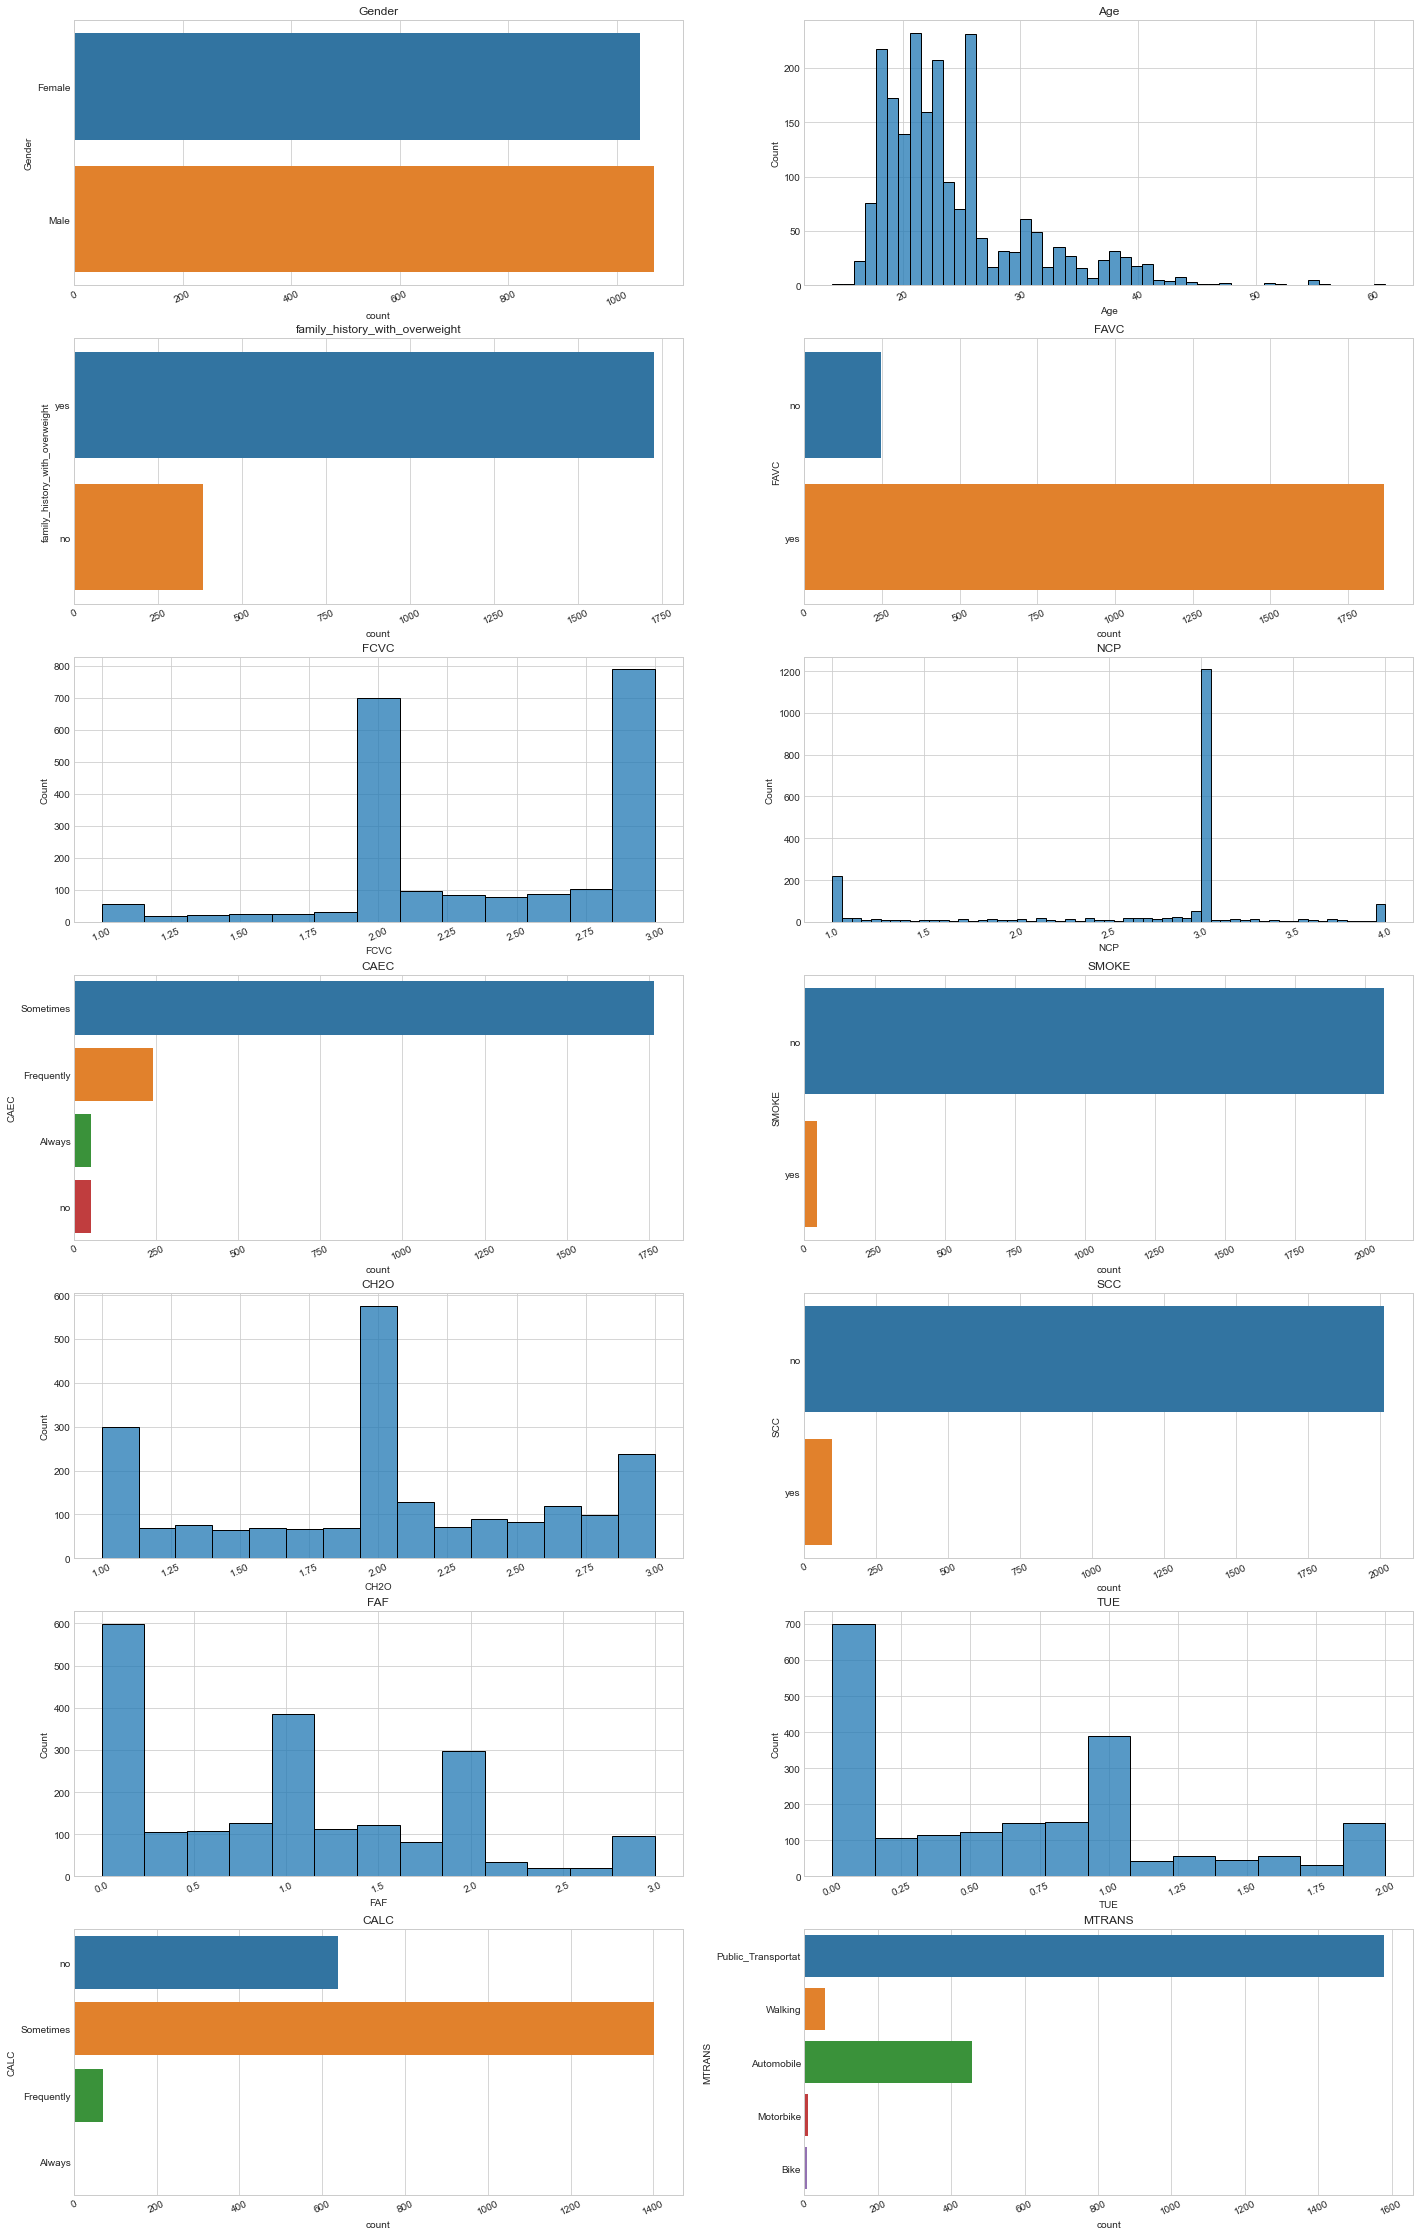

In [151]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df = df.drop(['Height','Weight'], axis=1)
dataset1 = Dataset(df.iloc[:,:-1],df.iloc[:,-1])
dataset1.plot_distribution()

对数据进行初步处理，得到清理后的数据

In [152]:
dic1 = {'Female':0,'Male':1}
df['Gender'] = df['Gender'].map(dic1)
dic2 = {'yes':1,'no':0}
df['family_history_with_overweight'] = df['family_history_with_overweight'].map(dic2)
df['SMOKE'] = df['SMOKE'].map(dic2)
df['SCC'] = df['SCC'].map(dic2)
df['FAVC'] = df['FAVC'].map(dic2)
dic3 = {'no':0,'Sometimes':1,'Frequently':2,'Always':3}
df['CAEC'] = df['CAEC'].map(dic3)
df['CALC'] = df['CALC'].map(dic3)
dic4 = {'Insufficient_Weight':-1, 'Normal_Weight':0,'Overweight_Level_I':1, 'Overweight_Level_II':2, 'Obesity_Type_I':3,'Obesity_Type_II':4,'Obesity_Type_III':5}
df['NObeyesdad'] = df['NObeyesdad'].map(dic4)
X = df.iloc[:,:-1]
y = df.iloc[:, -1]
dataset2 = Dataset(X,y)

## 4.建立SVM模型预测

### 4.1对X中的分类变量进行one-hot编码

In [153]:
dataset2.get_dummies()
dataset2.X

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,0,0,0,1,0
1,0,21.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,0,0,0,1,0
2,1,23.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,0,0,0,1,0
3,1,27.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,0,0,0,0,1
4,1,22.000000,0,0,2.0,1.0,1,0,2.000000,0,0.000000,0.000000,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,0,0,0,1,0
2107,0,21.982942,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,0,0,0,1,0
2108,0,22.524036,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,0,0,0,1,0
2109,0,24.361936,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,0,0,0,1,0


### 4.2对x进行标准化处理，并查看处理后的数据

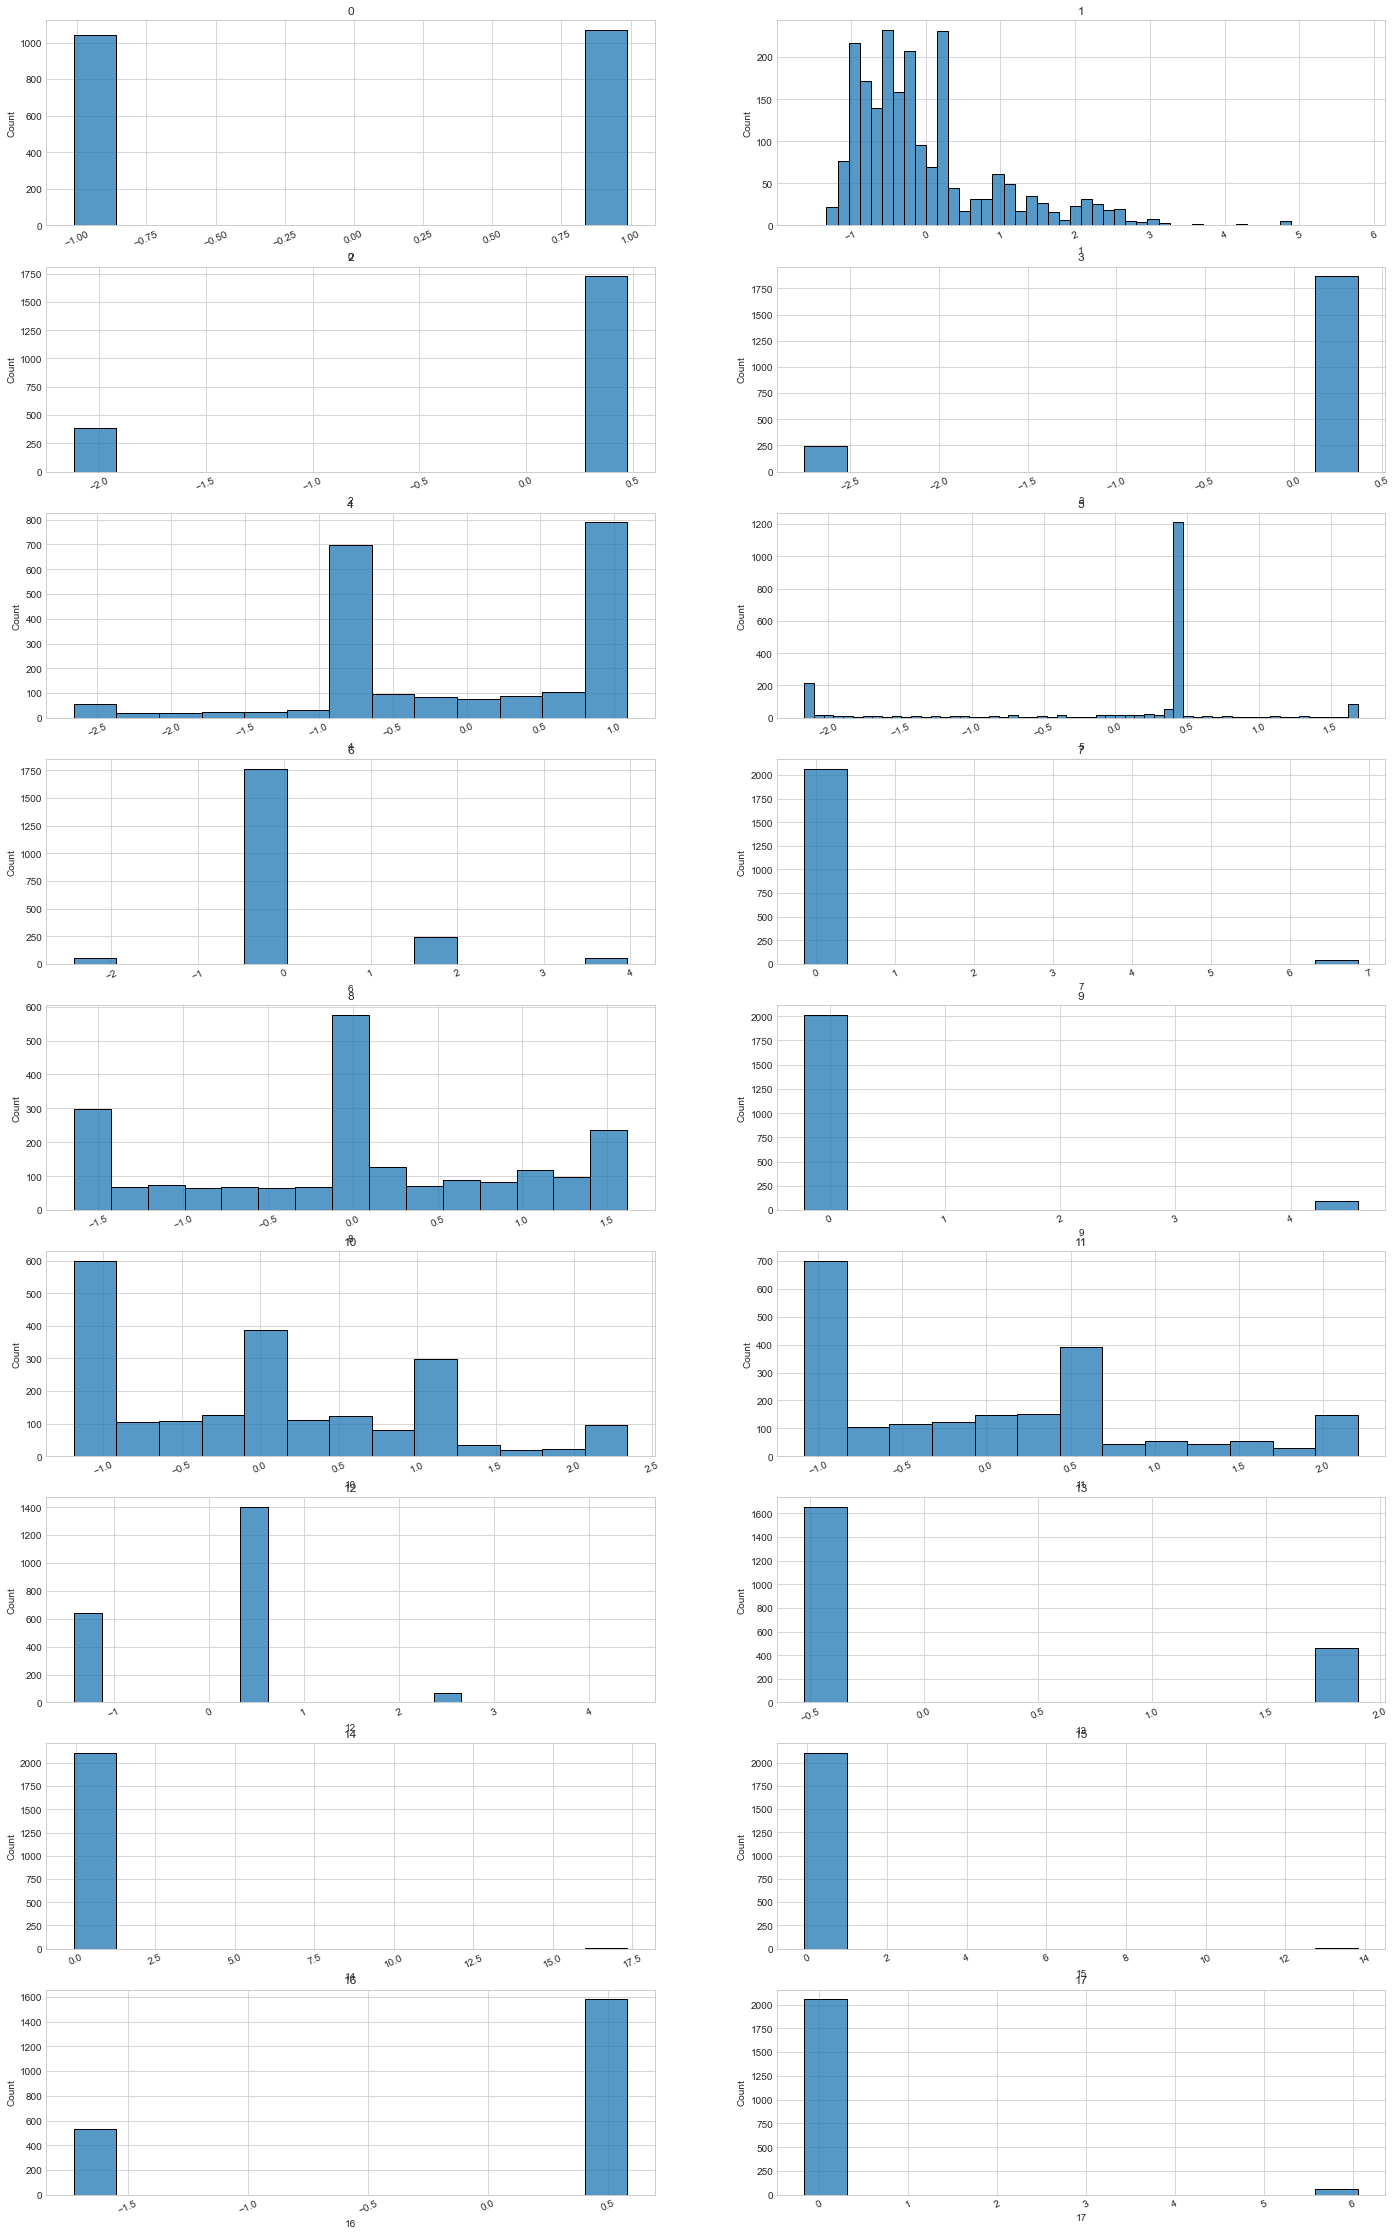

In [154]:
dataset2.Standard()
dataset2.plot_distribution()

把y展开为一个矩阵

In [155]:
dataset2.label_bin()
pd.DataFrame(dataset2.y)

,0,1,2,3,4,5,6
0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0
3,0,0,1,0,0,0,0
4,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...
2106,0,0,0,0,0,0,1
2107,0,0,0,0,0,0,1
2108,0,0,0,0,0,0,1
2109,0,0,0,0,0,0,1


### 4.3进行训练集的分割

In [156]:
dataset2.split_train_test(test_rate=.2)

### 4.4得到预测结果图

The roc_auc of 0 is 0.8930382466695316
The roc_auc of 1 is 0.6980634646726106
The roc_auc of 2 is 0.6743361135078132
The roc_auc of 3 is 0.6607213438735178
The roc_auc of 4 is 0.8019872547375482
The roc_auc of 5 is 0.9493625701172871
The roc_auc of 6 is 0.9997543601080815


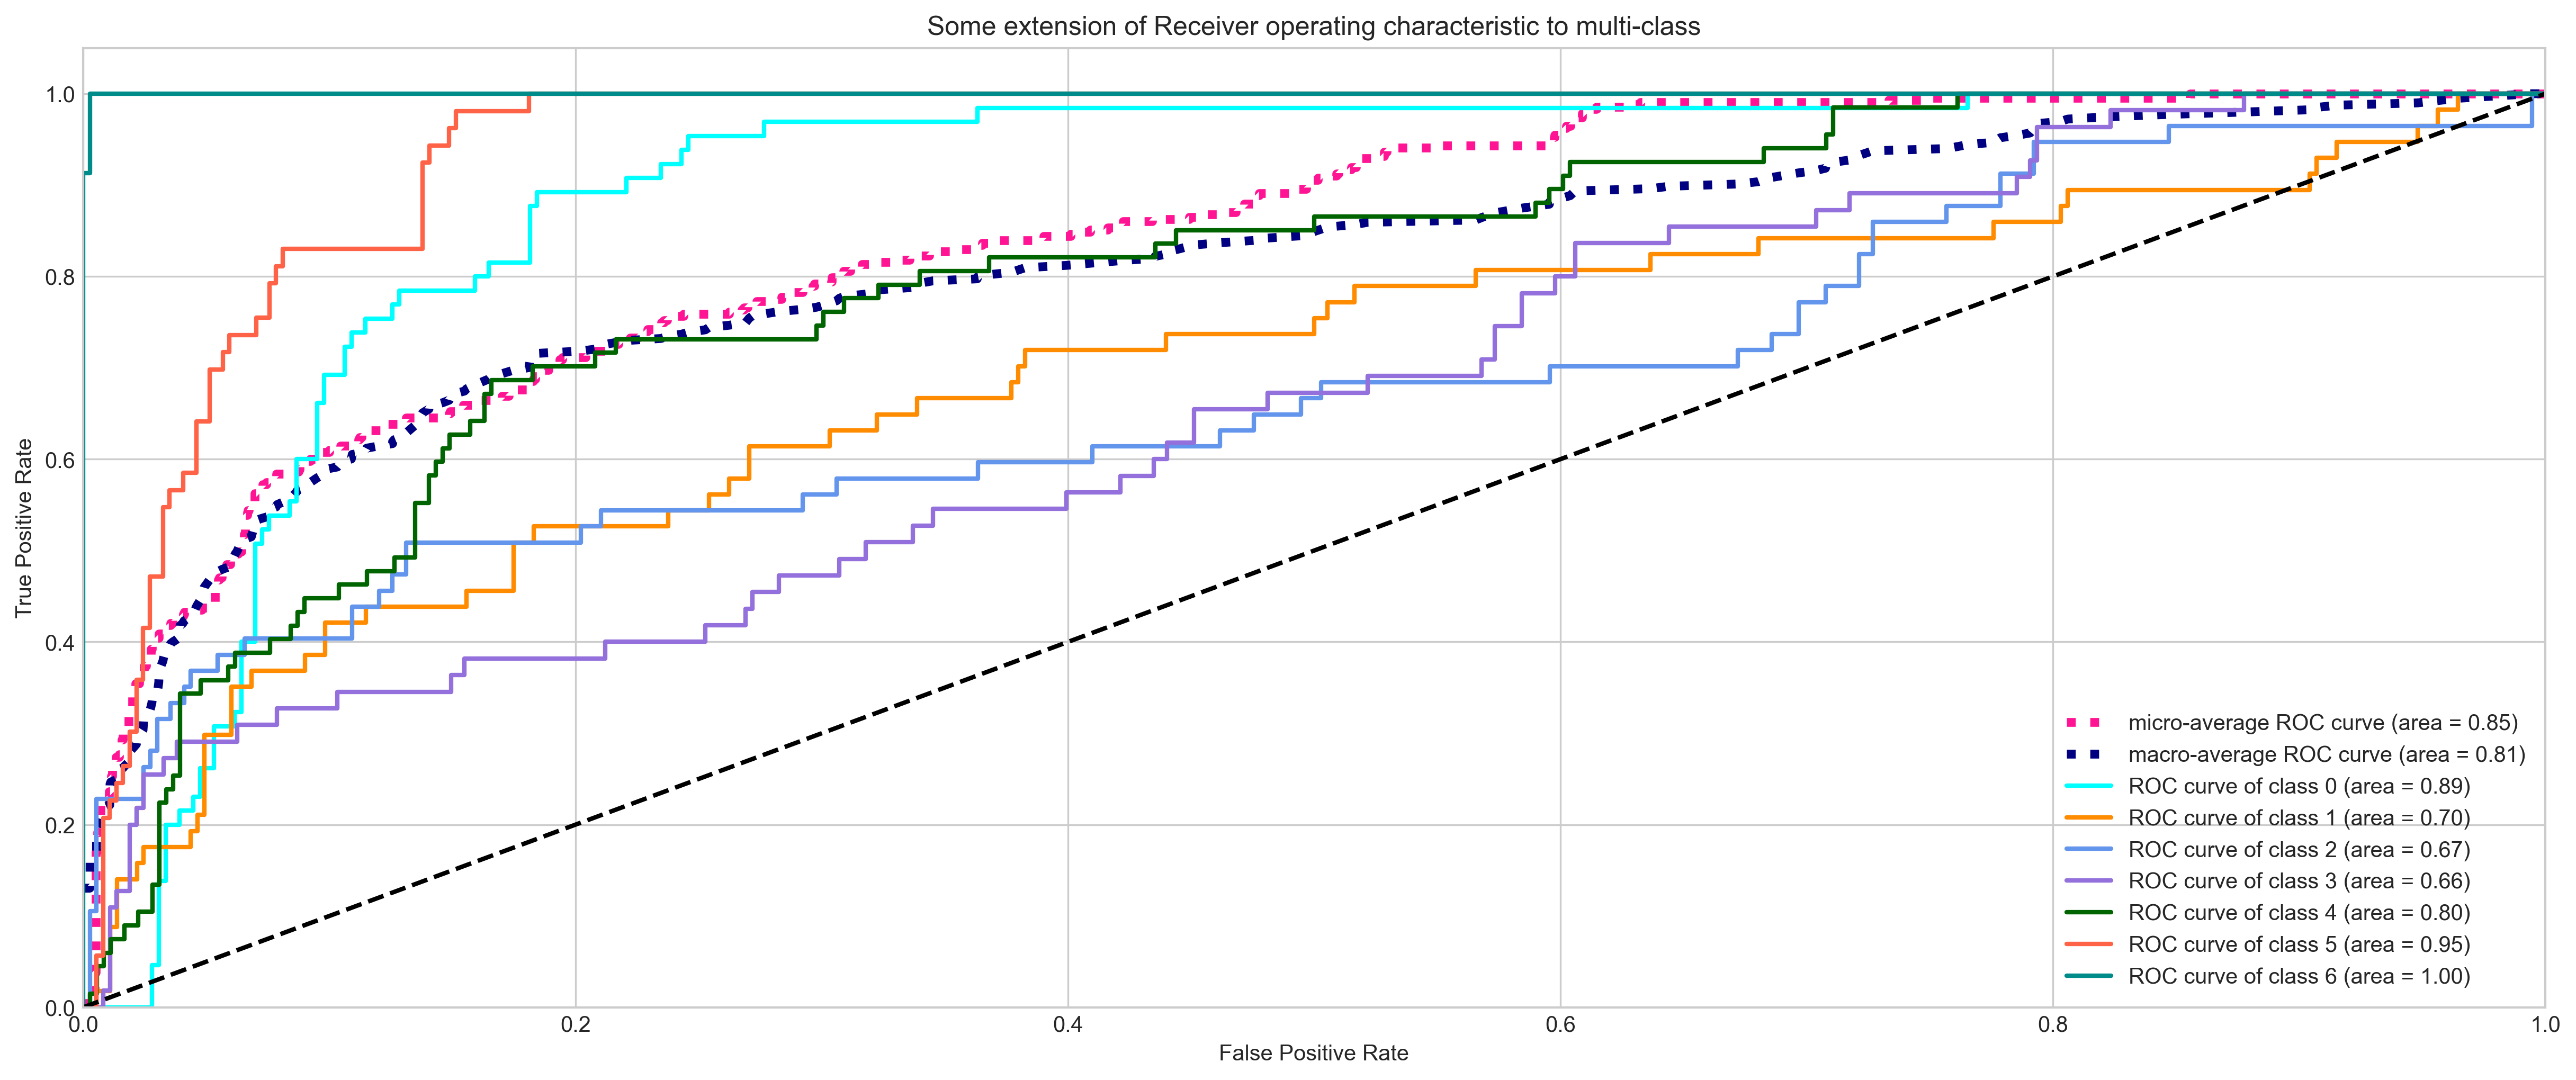

In [157]:
dataset2.svm_pred()